
# Presentation Figures Notebook

This notebook generates **placeholder figures** for the MSc thesis presentation,
using the **preprocessed embryo dataset**:

- Input images: `../data/embryo_dataset_silver/F0/<embryo_id>/*.jpg`
- Output figures: `../figures/`

It does **not** require a trained diffusion model. It only uses existing embryo
frames and a few simple schematic diagrams.


In [76]:

import os
import random
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import FancyBboxPatch, Circle

# Paths (this notebook is expected to live in the `diffusion/` folder)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_SILVER_DIR = os.path.join(BASE_DIR, "data", "embryo_dataset_silver", "F0")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

BASE_DIR, DATA_SILVER_DIR, FIGURES_DIR


('/mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis',
 '/mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/data/embryo_dataset_silver/F0',
 '/mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures')

In [77]:

def list_embryo_dirs():
    """Return a sorted list of embryo directories in the silver F0 dataset."""
    if not os.path.isdir(DATA_SILVER_DIR):
        raise FileNotFoundError(f"DATA_SILVER_DIR not found: {DATA_SILVER_DIR}")
    dirs = sorted(d for d in glob(os.path.join(DATA_SILVER_DIR, "*")) if os.path.isdir(d))
    if not dirs:
        raise RuntimeError(f"No embryo folders found in {DATA_SILVER_DIR}")
    return dirs


def list_frames(embryo_dir):
    """Return a sorted list of frame image paths (jpg / jpeg / png) in an embryo dir."""
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    files = []
    for pat in patterns:
        files.extend(glob(os.path.join(embryo_dir, pat)))
    files = sorted(files)
    if not files:
        raise RuntimeError(f"No image files found in {embryo_dir}")
    return files


def load_image_gray(path):
    """Load an image as grayscale float array in [0,1]."""
    img = Image.open(path).convert("L")  # L = grayscale
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr


embryo_dirs = list_embryo_dirs()
len(embryo_dirs)


704

## 1. Time-lapse sequence from a single embryo

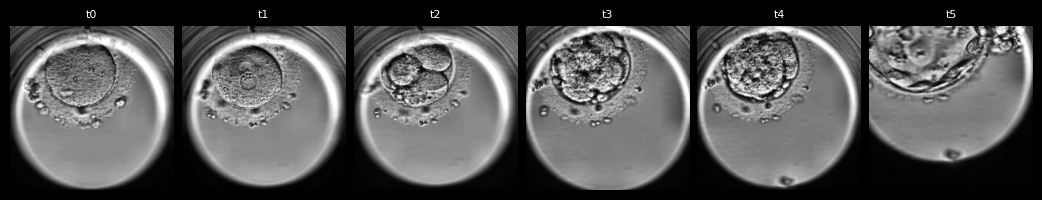

Saved time-lapse sequence to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/time_lapse_sequence.png


In [ ]:

def create_time_lapse_sequence(save_path, num_frames=8):
    """Pick one embryo and show a sequence of frames over time."""
    embryo_dir = random.choice(embryo_dirs)
    frame_paths = list_frames(embryo_dir)

    if len(frame_paths) < num_frames:
        num_frames = len(frame_paths)

    indices = np.linspace(0, len(frame_paths) - 1, num_frames, dtype=int)
    selected = [frame_paths[i] for i in indices]

    fig, axes = plt.subplots(1, num_frames, figsize=(2.2 * num_frames, 2.5))
    if num_frames == 1:
        axes = [axes]

    fig.patch.set_facecolor("black")

    for ax, path, t_idx in zip(axes, selected, range(num_frames)):
        img = load_image_gray(path)
        ax.imshow(img, cmap="gray")
        ax.set_axis_off()
        ax.set_title(f"t{t_idx}", color="white", fontsize=8)

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


time_lapse_path = os.path.join(FIGURES_DIR, "time_lapse_sequence.png")
create_time_lapse_sequence(time_lapse_path)
print("Saved time-lapse sequence to:", time_lapse_path)


## 2. Random embryo examples grid (phase placeholders)

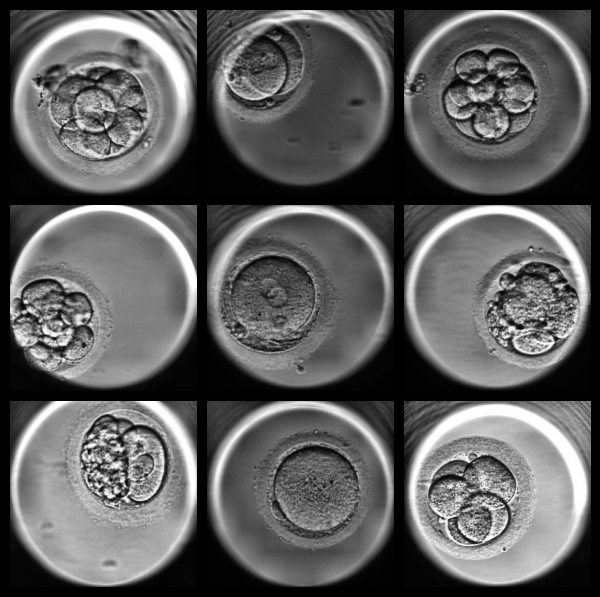

Saved random examples grid to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/development_phases_placeholder.png


In [79]:

def create_random_examples_grid(save_path, rows=3, cols=3):
    """Create a grid of random embryo frames from different embryos.

    This serves as a placeholder for phase examples.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.5 * rows))
    fig.patch.set_facecolor("black")

    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            embryo_dir = random.choice(embryo_dirs)
            frame_paths = list_frames(embryo_dir)
            path = random.choice(frame_paths)
            img = load_image_gray(path)
            ax.imshow(img, cmap="gray")
            ax.set_axis_off()

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


phases_grid_path = os.path.join(FIGURES_DIR, "development_phases_placeholder.png")
create_random_examples_grid(phases_grid_path)
print("Saved random examples grid to:", phases_grid_path)


## 3. Training pairs (current vs future frame)

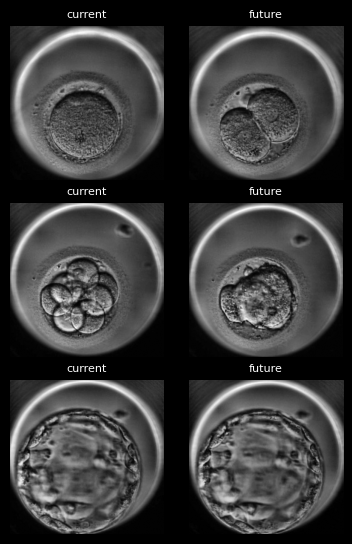

Saved training pairs figure to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/training_pairs_example.png


In [80]:

def create_training_pairs_example(save_path, num_pairs=3):
    """From one embryo, create pairs of frames (t, t+Δt)."""
    embryo_dir = random.choice(embryo_dirs)
    frame_paths = list_frames(embryo_dir)

    if len(frame_paths) < 2:
        raise RuntimeError("Not enough frames to form pairs.")

    num_pairs = min(num_pairs, len(frame_paths) - 1)
    starts = np.linspace(0, len(frame_paths) - 2, num_pairs, dtype=int)
    delta = max(1, len(frame_paths) // 4)

    fig, axes = plt.subplots(num_pairs, 2, figsize=(4.5, 2.2 * num_pairs))
    fig.patch.set_facecolor("black")

    for row, s_idx in enumerate(starts):
        f_idx = min(s_idx + delta, len(frame_paths) - 1)
        paths = [frame_paths[s_idx], frame_paths[f_idx]]
        titles = ["current", "future"]

        for col in range(2):
            ax = axes[row, col] if num_pairs > 1 else axes[col]
            img = load_image_gray(paths[col])
            ax.imshow(img, cmap="gray")
            ax.set_axis_off()
            ax.set_title(titles[col], color="white", fontsize=8)

    plt.subplots_adjust(wspace=0.05, hspace=0.15)
    fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


training_pairs_path = os.path.join(FIGURES_DIR, "training_pairs_example.png")
create_training_pairs_example(training_pairs_path)
print("Saved training pairs figure to:", training_pairs_path)


## 4. Diffusion concept: from noise to image

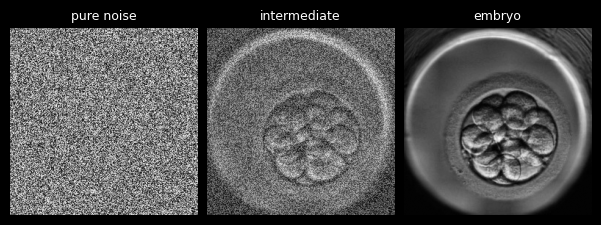

Saved noise-to-image figure to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/diffusion_noise_to_image.png


In [81]:

def create_noise_to_image_figure(save_path):
    """Show pure noise -> intermediate -> real embryo frame."""
    embryo_dir = random.choice(embryo_dirs)
    frame_path = random.choice(list_frames(embryo_dir))
    img = load_image_gray(frame_path)
    h, w = img.shape

    noise = np.random.rand(h, w)
    mixed = 0.5 * noise + 0.5 * img

    images = [noise, mixed, img]
    titles = ["pure noise", "intermediate", "embryo"]

    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.7))
    fig.patch.set_facecolor("black")

    for ax, arr, title in zip(axes, images, titles):
        ax.imshow(arr, cmap="gray")
        ax.set_axis_off()
        ax.set_title(title, color="white", fontsize=9)

    plt.subplots_adjust(wspace=0.05)
    fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


noise_image_path = os.path.join(FIGURES_DIR, "diffusion_noise_to_image.png")
create_noise_to_image_figure(noise_image_path)
print("Saved noise-to-image figure to:", noise_image_path)


## 5. Forward vs reverse diffusion schematic

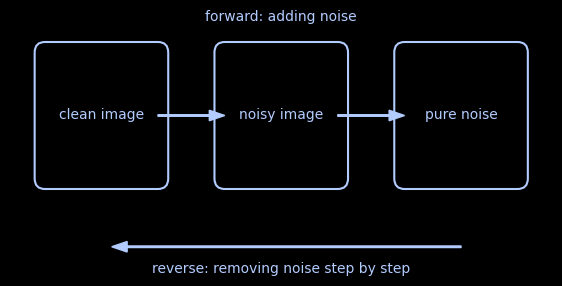

Saved forward/reverse diagram to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/diffusion_forward_reverse.png


In [82]:


def create_forward_reverse_diagram(save_path):
    """Create a schematic diagram: clean -> noisy (forward) and back (reverse)."""
    plt.close("all")
    fig, ax = plt.subplots(figsize=(7, 3))

    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.axis("off")

    xs = [0.15, 0.5, 0.85]
    y = 0.65
    labels = ["clean image", "noisy image", "pure noise"]

    color = (0.7, 0.8, 1.0)

    for x, label in zip(xs, labels):
        box = FancyBboxPatch(
            (x - 0.11, y - 0.12),
            0.22,
            0.24,
            boxstyle="round,pad=0.02",
            linewidth=1.5,
            edgecolor=color,
            facecolor=(0, 0, 0, 0.7),
        )
        ax.add_patch(box)
        ax.text(
            x,
            y,
            label,
            color=color,
            ha="center",
            va="center",
            fontsize=10,
        )

    arrow_kwargs = dict(
        width=0.003,
        head_width=0.02,
        head_length=0.03,
        length_includes_head=True,
        color=color,
    )
    ax.arrow(xs[0] + 0.11, y, xs[1] - xs[0] - 0.22, 0, **arrow_kwargs)
    ax.arrow(xs[1] + 0.11, y, xs[2] - xs[1] - 0.22, 0, **arrow_kwargs)
    ax.text(0.5, y + 0.18, "forward: adding noise", color=color, ha="center", fontsize=10)

    y2 = 0.35
    ax.text(0.5, y2, "reverse: removing noise step by step", color=color, ha="center", fontsize=10)
    ax.arrow(xs[2], y2 + 0.05, -(xs[2] - xs[0] - 0.02), 0, **arrow_kwargs)

    fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


forward_reverse_path = os.path.join(FIGURES_DIR, "diffusion_forward_reverse.png")
create_forward_reverse_diagram(forward_reverse_path)
print("Saved forward/reverse diagram to:", forward_reverse_path)


## 6. Conditional generation schematic

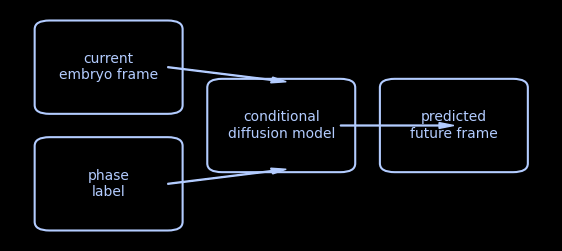

Saved conditional generation diagram to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/conditional_generation_diagram.png


In [83]:

def create_conditional_generation_diagram(save_path):
    """Schematic: current frame + phase label -> model -> future frame."""
    plt.close("all")
    fig, ax = plt.subplots(figsize=(7, 3))

    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.axis("off")

    color = (0.7, 0.8, 1.0)

    def add_box(center_x, center_y, text, width=0.24, height=0.26):
        box = FancyBboxPatch(
            (center_x - width / 2, center_y - height / 2),
            width,
            height,
            boxstyle="round,pad=0.03",
            linewidth=1.5,
            edgecolor=color,
            facecolor=(0, 0, 0, 0.7),
        )
        ax.add_patch(box)
        ax.text(
            center_x,
            center_y,
            text,
            color=color,
            ha="center",
            va="center",
            fontsize=10,
        )

    add_box(0.15, 0.65, "current\nembryo frame")
    add_box(0.15, 0.25, "phase\nlabel")
    add_box(0.5, 0.45, "conditional\ndiffusion model")
    add_box(0.85, 0.45, "predicted\nfuture frame")

    arrow_kwargs = dict(
        width=0.003,
        head_width=0.02,
        head_length=0.03,
        length_includes_head=True,
        color=color,
    )

    ax.arrow(0.15 + 0.12, 0.65, 0.5 - 0.26, -0.05, **arrow_kwargs)
    ax.arrow(0.15 + 0.12, 0.25, 0.5 - 0.26, 0.05, **arrow_kwargs)
    ax.arrow(0.5 + 0.12, 0.45, 0.85 - 0.62, 0, **arrow_kwargs)

    fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


cond_gen_path = os.path.join(FIGURES_DIR, "conditional_generation_diagram.png")
create_conditional_generation_diagram(cond_gen_path)
print("Saved conditional generation diagram to:", cond_gen_path)


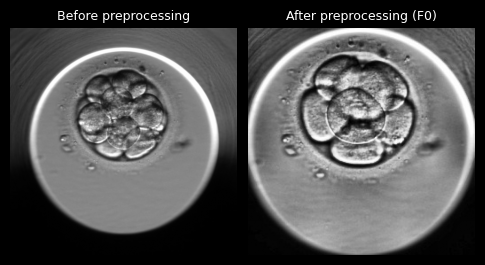

Saved before/after preprocessing figure to: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/figures/preprocessing_before_after.png


In [84]:
BRONZE_DIR = os.path.join(BASE_DIR, "data", "embryo_dataset_bronze")

def list_bronze_frames(embryo_id):
    embryo_dir = os.path.join(BRONZE_DIR, embryo_id)
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    files = []
    for pat in patterns:
        files.extend(glob(os.path.join(embryo_dir, pat)))
    files = sorted(files)
    if not files:
        raise RuntimeError(f"No raw frames found in {embryo_dir}")
    return files

# Διαλέγουμε ένα embryo που υπάρχει στο silver (F0)
embryo_silver_dir = random.choice(embryo_dirs)
embryo_id = os.path.basename(embryo_silver_dir)

bronze_frames = list_bronze_frames(embryo_id)
silver_frames = list_frames(embryo_silver_dir)  # ήδη ορισμένη συνάρτηση

# Χρησιμοποιούμε το ίδιο index όπου γίνεται, για περίπου ίδιο timepoint
min_len = min(len(bronze_frames), len(silver_frames))
idx = min_len // 2

bronze_path = bronze_frames[idx]
silver_path = silver_frames[idx]

img_bronze = load_image_gray(bronze_path)
img_silver = load_image_gray(silver_path)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
fig.patch.set_facecolor("black")

axes[0].imshow(img_bronze, cmap="gray")
axes[0].set_title("Before preprocessing", color="white", fontsize=9)
axes[0].axis("off")

axes[1].imshow(img_silver, cmap="gray")
axes[1].set_title("After preprocessing (F0)", color="white", fontsize=9)
axes[1].axis("off")

plt.subplots_adjust(wspace=0.05)
save_path = os.path.join(FIGURES_DIR, "preprocessing_before_after.png")
fig.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

print("Saved before/after preprocessing figure to:", save_path)